# Property Intelligence — Machine Learning Cluster Analysis

Every property has dozens of numbers. Price, size, bedrooms, how long it's been listed, whether the seller dropped the price, location coordinates, and more.

**No human can compare 15+ variables across 200 properties at once.**

So we let the machine do it:
1. **Engineer** new signals from the raw data (value gaps, distress ratios, spatial features)
2. **Compress** all variables into 3 dimensions (PCA) — like an X-ray of each property's DNA
3. **Find** the natural groups (KMeans clustering) — which properties are truly similar
4. **Profile** each group — what makes it unique
5. **Recommend** — which group is where the money is

---

In [10]:
import importlib, warnings
warnings.filterwarnings("ignore")

import utils, utils.filters, utils.display, utils.loader
importlib.reload(utils.filters)
importlib.reload(utils.display)
importlib.reload(utils.loader)
importlib.reload(utils)

from utils import load_data, clean, flip_score
from utils.display import picks_table

In [11]:
df_raw = load_data()

  Loaded 200 listings from cache.


---

## Step 1 — Feature Engineering

We don't just use raw numbers. We build **new signals** that capture what investors actually care about.

In [12]:
import numpy as np
import pandas as pd

df = flip_score(clean(df_raw))

# ── DERIVED FEATURES ──

if "baths" in df.columns and "beds" in df.columns:
    df["bath_per_bed"] = (df["baths"] / df["beds"].replace(0, np.nan)).round(2)

if "lot_sqft" in df.columns and "sqft" in df.columns:
    df["lot_to_living"] = (df["lot_sqft"] / df["sqft"].replace(0, np.nan)).round(2)

if "price_reduced" in df.columns and "price" in df.columns:
    df["discount_pct"] = ((df["price_reduced"].fillna(0)) / (df["price"] + df["price_reduced"].fillna(0)) * 100).round(1)

if "last_sold_price" in df.columns and "price" in df.columns:
    df["price_vs_last_sold"] = (df["price"] / df["last_sold_price"].replace(0, np.nan)).round(2)

if "price_per_sqft" in df.columns and "beds" in df.columns:
    med_ppsf = df.groupby("beds")["price_per_sqft"].transform("median")
    df["ppsf_deviation"] = ((df["price_per_sqft"] / med_ppsf.replace(0, np.nan) - 1) * 100).round(1)

if "days_on_market" in df.columns:
    avg_dom = df["days_on_market"].mean()
    if avg_dom > 0:
        df["relative_dom"] = (df["days_on_market"] / avg_dom).round(2)

df["is_foreclosure_n"] = df.get("is_foreclosure", pd.Series(False, index=df.index)).fillna(False).astype(int)
df["is_reduced_n"] = df.get("is_price_reduced", pd.Series(False, index=df.index)).fillna(False).astype(int)

FEATURES = [
    "price", "sqft", "beds", "baths", "lot_sqft",
    "price_per_sqft", "sqft_per_bed", "bath_per_bed", "lot_to_living",
    "days_on_market", "relative_dom",
    "discount_pct", "price_vs_last_sold", "ppsf_deviation",
    "is_foreclosure_n", "is_reduced_n",
    "lat", "lon",
    "ax_value_gap", "ax_distress", "ax_market_reject", "ax_seller_weak",
    "flip_score",
]
available = [c for c in FEATURES if c in df.columns]

print(f"{len(df)} properties × {len(available)} engineered features")
print(f"\nFeatures used:")
for i, f in enumerate(available):
    print(f"  {i+1:2d}. {f}")

200 properties × 23 engineered features

Features used:
   1. price
   2. sqft
   3. beds
   4. baths
   5. lot_sqft
   6. price_per_sqft
   7. sqft_per_bed
   8. bath_per_bed
   9. lot_to_living
  10. days_on_market
  11. relative_dom
  12. discount_pct
  13. price_vs_last_sold
  14. ppsf_deviation
  15. is_foreclosure_n
  16. is_reduced_n
  17. lat
  18. lon
  19. ax_value_gap
  20. ax_distress
  21. ax_market_reject
  22. ax_seller_weak
  23. flip_score


---

## Step 2 — PCA Compression

We take all those features and **squeeze them into 3 dimensions** — keeping as much information as possible.

Think of it as going from a 23-page report on each property to a **3-number fingerprint** that still tells you almost everything.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

X_raw = df[available].copy()
X_filled = SimpleImputer(strategy="median").fit_transform(X_raw)
X_scaled = StandardScaler().fit_transform(X_filled)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df["PC1"], df["PC2"], df["PC3"] = X_pca[:, 0], X_pca[:, 1], X_pca[:, 2]

var = pca.explained_variance_ratio_
print(f"Variance captured:")
print(f"  PC1  {var[0]:.1%}   PC2  {var[1]:.1%}   PC3  {var[2]:.1%}")
print(f"  TOTAL: {var.sum():.1%} of all information preserved in 3 dimensions")

Variance captured:
  PC1  22.0%   PC2  16.0%   PC3  8.9%
  TOTAL: 46.9% of all information preserved in 3 dimensions


### What drives each dimension?

Bars pointing right = that variable pushes a property further along that axis.  
Red bars = negative relationship (higher value pulls the other way).

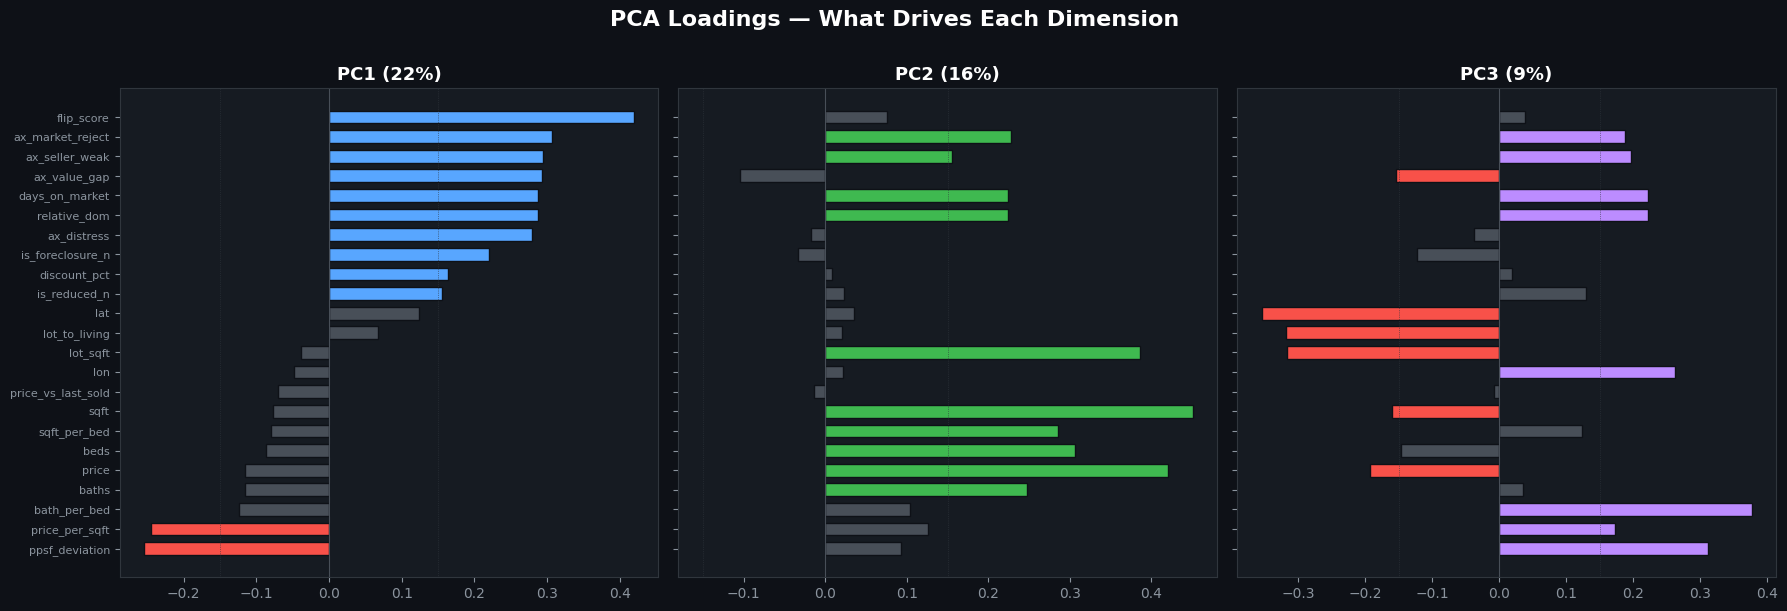

In [14]:
import matplotlib.pyplot as plt

DARK = {"figure.facecolor": "#0e1117", "axes.facecolor": "#161b22",
        "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9",
        "text.color": "#c9d1d9", "xtick.color": "#8b949e", "ytick.color": "#8b949e"}

loadings = pd.DataFrame(pca.components_.T, index=available,
                         columns=[f"PC1 ({var[0]:.0%})", f"PC2 ({var[1]:.0%})", f"PC3 ({var[2]:.0%})"])

pc_colors = ["#58a6ff", "#3fb950", "#bc8cff"]

with plt.rc_context(DARK):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i, (col, color) in enumerate(zip(loadings.columns, pc_colors)):
        vals = loadings[col].sort_values()
        bar_c = ["#f85149" if v < -0.15 else (color if v > 0.15 else "#484f58") for v in vals]
        axes[i].barh(vals.index, vals.values, color=bar_c, edgecolor="#0e1117", height=0.65)
        axes[i].set_title(col, fontsize=13, fontweight="bold", color="white")
        axes[i].axvline(0, color="#484f58", lw=0.8)
        axes[i].axvline(-0.15, color="#30363d", lw=0.5, ls=":")
        axes[i].axvline(0.15, color="#30363d", lw=0.5, ls=":")
        axes[i].tick_params(axis="y", labelsize=8)
        axes[i].spines[:].set_color("#30363d")
    fig.suptitle("PCA Loadings — What Drives Each Dimension",
                 fontsize=16, fontweight="bold", color="white", y=1.01)
    plt.tight_layout()
    plt.show()

---

## Step 3 — Finding the Optimal Number of Clusters

Instead of guessing, we test K=2 through K=8 and measure two things:
- **Inertia** (elbow method) — how tight are the groups?
- **Silhouette score** — how well-separated are they? (higher = cleaner groups)

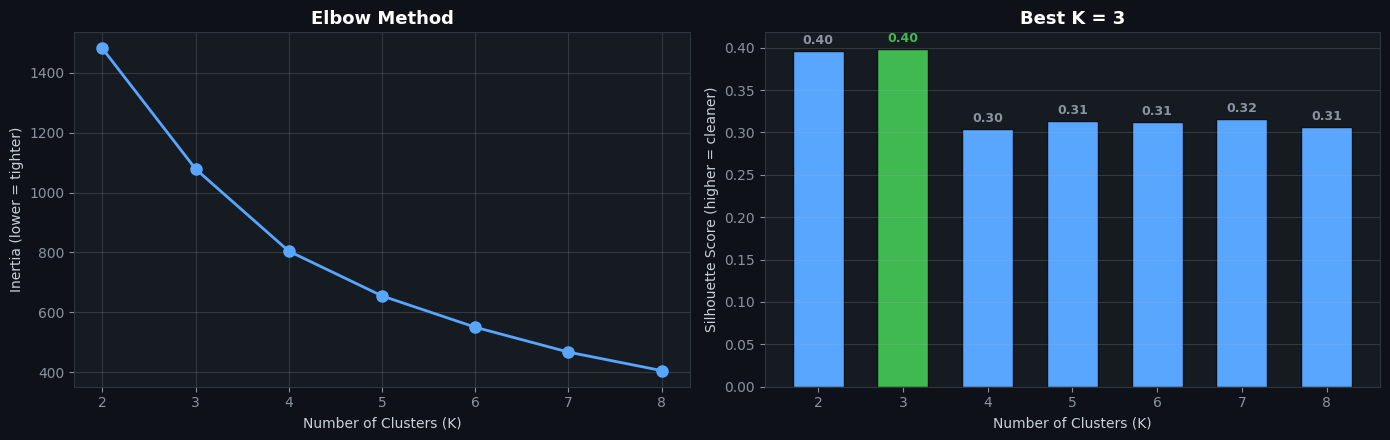


  Optimal clusters: 3 (silhouette = 0.398)


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

best_k = list(K_range)[np.argmax(silhouettes)]

with plt.rc_context(DARK):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    ax1.plot(list(K_range), inertias, "o-", color="#58a6ff", lw=2, markersize=8)
    ax1.set_xlabel("Number of Clusters (K)")
    ax1.set_ylabel("Inertia (lower = tighter)")
    ax1.set_title("Elbow Method", fontsize=13, fontweight="bold", color="white")
    ax1.grid(True, alpha=0.2)
    ax1.spines[:].set_color("#30363d")

    bar_colors = ["#3fb950" if k == best_k else "#58a6ff" for k in K_range]
    ax2.bar(list(K_range), silhouettes, color=bar_colors, edgecolor="#0e1117", width=0.6)
    ax2.set_xlabel("Number of Clusters (K)")
    ax2.set_ylabel("Silhouette Score (higher = cleaner)")
    ax2.set_title(f"Best K = {best_k}", fontsize=13, fontweight="bold", color="white")
    for i, (k, s) in enumerate(zip(K_range, silhouettes)):
        ax2.text(k, s + 0.008, f"{s:.2f}", ha="center", fontsize=9,
                 color="#3fb950" if k == best_k else "#8b949e", fontweight="bold")
    ax2.grid(axis="y", alpha=0.2)
    ax2.spines[:].set_color("#30363d")

    plt.tight_layout()
    plt.show()

print(f"\n  Optimal clusters: {best_k} (silhouette = {max(silhouettes):.3f})")

---

## Step 4 — Clustering + Profiling

In [16]:
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=42)
df["pca_cluster"] = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

profile_cols = ["price", "sqft", "price_per_sqft", "days_on_market",
                "flip_score", "ppsf_deviation", "discount_pct", "relative_dom"]
profile_cols = [c for c in profile_cols if c in df.columns]

profiles = df.groupby("pca_cluster")[profile_cols].median().round(1)
profiles["count"] = df.groupby("pca_cluster").size()

rank_order = profiles["flip_score"].sort_values(ascending=False).index.tolist()
LABELS = ["BEST OPPORTUNITIES", "WORTH A LOOK", "AVERAGE MARKET", "PREMIUM / NO EDGE",
          "CLUSTER E", "CLUSTER F", "CLUSTER G", "CLUSTER H"]
EMOJIS = ["\U0001f525", "\U0001f7e1", "\U0001f535", "\u26aa", "\u2b1c", "\u2b1b", "\u25fb", "\u25fc"]
PCOLORS_LIST = ["#3fb950", "#d29922", "#58a6ff", "#8b949e", "#bc8cff", "#f0883e", "#79c0ff", "#f85149"]

cluster_meta = {}
for i, c in enumerate(rank_order):
    cluster_meta[c] = {
        "label": f"{EMOJIS[i]} {LABELS[i]}",
        "color": PCOLORS_LIST[i],
        "rank": i,
    }

df["pca_label"] = df["pca_cluster"].map(lambda x: cluster_meta[x]["label"])
color_map = {m["label"]: m["color"] for m in cluster_meta.values()}

print(f"{'':2s} {'CLUSTER':<26s} {'N':>4s}  {'Med Price':>10s}  {'$/sqft':>7s}  {'DOM':>5s}  {'Flip':>5s}")
print("  " + "─" * 68)
for c in rank_order:
    m = cluster_meta[c]
    p = profiles.loc[c]
    print(f"  {m['label']:<26s} {int(p['count']):4d}  ${p.get('price',0):>9,.0f}  ${p.get('price_per_sqft',0):>6,.0f}  {p.get('days_on_market',0):5.0f}  {p.get('flip_score',0):5.0f}")

   CLUSTER                       N   Med Price   $/sqft    DOM   Flip
  ────────────────────────────────────────────────────────────────────
  🔥 BEST OPPORTUNITIES         61  $   69,995  $    47    164      5
  🟡 WORTH A LOOK                1  $7,000,000  $   378    392      4
  🔵 AVERAGE MARKET            138  $  189,000  $   106     19      0


### Cluster Personality — Radar Chart

Each cluster has a "shape" — a personality defined by how it scores across the key investment dimensions.  
Bigger shape = more extreme on that axis.

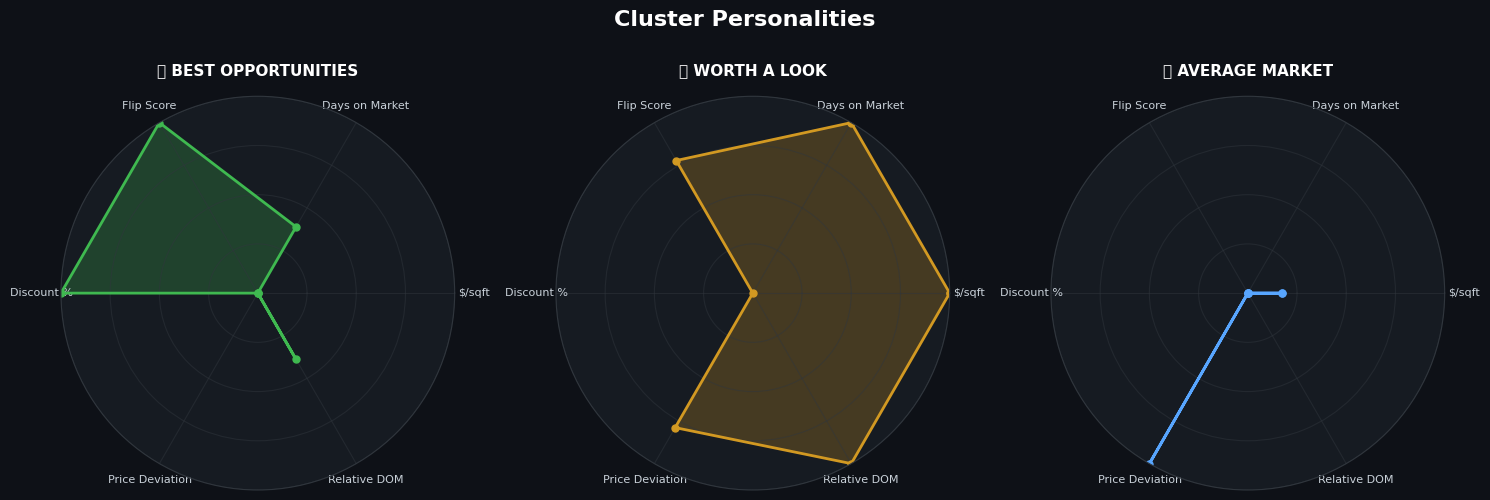

In [17]:
radar_cols = [c for c in ["price_per_sqft", "days_on_market", "flip_score",
                           "discount_pct", "ppsf_deviation", "relative_dom"] if c in df.columns]

if len(radar_cols) >= 4:
    from sklearn.preprocessing import MinMaxScaler
    radar_data = df.groupby("pca_cluster")[radar_cols].median()

    scaler_r = MinMaxScaler()
    radar_norm = pd.DataFrame(scaler_r.fit_transform(radar_data),
                              index=radar_data.index, columns=radar_data.columns)

    angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
    angles += angles[:1]

    nice_names = {"price_per_sqft": "$/sqft", "days_on_market": "Days on Market",
                  "flip_score": "Flip Score", "discount_pct": "Discount %",
                  "ppsf_deviation": "Price Deviation", "relative_dom": "Relative DOM"}
    labels_r = [nice_names.get(c, c) for c in radar_cols]

    n_clusters = len(rank_order)
    cols_per_row = min(n_clusters, 4)
    rows = (n_clusters + cols_per_row - 1) // cols_per_row

    with plt.rc_context(DARK):
        fig, axes_r = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 5 * rows),
                                    subplot_kw=dict(polar=True))
        if n_clusters == 1:
            axes_r = np.array([axes_r])
        axes_flat = axes_r.flatten() if hasattr(axes_r, 'flatten') else [axes_r]

        for idx, c in enumerate(rank_order):
            ax = axes_flat[idx]
            m = cluster_meta[c]
            vals = radar_norm.loc[c].tolist()
            vals += vals[:1]

            ax.fill(angles, vals, alpha=0.25, color=m["color"])
            ax.plot(angles, vals, "o-", color=m["color"], lw=2, markersize=5)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels_r, fontsize=8, color="#c9d1d9")
            ax.set_ylim(0, 1)
            ax.set_yticks([0.25, 0.5, 0.75, 1.0])
            ax.set_yticklabels(["", "", "", ""])
            ax.set_title(m["label"], fontsize=11, fontweight="bold", color="white", pad=15)
            ax.set_facecolor("#161b22")
            ax.spines["polar"].set_color("#30363d")
            ax.grid(color="#30363d", alpha=0.5)

        for idx in range(len(rank_order), len(axes_flat)):
            axes_flat[idx].set_visible(False)

        fig.suptitle("Cluster Personalities", fontsize=16, fontweight="bold", color="white", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("Not enough features for radar chart.")

---

## Step 5 — The 3D Map

Every dot = one property, positioned by its DNA (all features compressed to 3 axes).  
Colors = the natural groups the machine found.  
Stars = cluster centers (the "average" property in each group).  

**Drag** to spin. **Hover** for details. **Click** legend items to toggle.

In [18]:
import plotly.graph_objects as go

fig3d = go.Figure()

for c in rank_order:
    m = cluster_meta[c]
    sub = df[df["pca_cluster"] == c]
    hover = []
    for _, r in sub.iterrows():
        a = (r.get("address") or "?")[:30]
        p = f"${r['price']:,.0f}" if pd.notna(r.get("price")) else "—"
        sq = f"{int(r['sqft'])} sqft" if pd.notna(r.get("sqft")) else ""
        ppsf = f"${r['price_per_sqft']:,.0f}/sqft" if pd.notna(r.get("price_per_sqft")) else ""
        dom = f"{int(r['days_on_market'])}d" if pd.notna(r.get("days_on_market")) else ""
        fl = f"Flip: {int(r['flip_score'])}/10" if pd.notna(r.get("flip_score")) else ""
        hover.append(f"<b>{a}</b><br>{p} · {sq} · {ppsf}<br>DOM {dom} · {fl}")

    fig3d.add_trace(go.Scatter3d(
        x=sub["PC1"], y=sub["PC2"], z=sub["PC3"],
        mode="markers", name=m["label"],
        marker=dict(size=5, color=m["color"], opacity=0.85,
                    line=dict(width=0.3, color="#0e1117")),
        hovertext=hover, hoverinfo="text",
    ))

for c in rank_order:
    m = cluster_meta[c]
    cx, cy, cz = centroids[c]
    fig3d.add_trace(go.Scatter3d(
        x=[cx], y=[cy], z=[cz], mode="markers",
        name=f"{m['label']} center",
        marker=dict(size=12, color=m["color"], symbol="diamond",
                    opacity=1, line=dict(width=2, color="white")),
        hovertext=f"<b>CENTER</b><br>{m['label']}", hoverinfo="text",
        showlegend=False,
    ))

fig3d.update_layout(
    template="plotly_dark",
    paper_bgcolor="#0e1117", plot_bgcolor="#0e1117",
    title=dict(text="Property DNA — 3D Cluster Map", font=dict(size=20, color="white")),
    scene=dict(
        xaxis_title=f"PC1 ({var[0]:.0%})",
        yaxis_title=f"PC2 ({var[1]:.0%})",
        zaxis_title=f"PC3 ({var[2]:.0%})",
        xaxis=dict(backgroundcolor="#161b22", gridcolor="#21262d", showbackground=True),
        yaxis=dict(backgroundcolor="#161b22", gridcolor="#21262d", showbackground=True),
        zaxis=dict(backgroundcolor="#161b22", gridcolor="#21262d", showbackground=True),
        camera=dict(eye=dict(x=1.8, y=1.8, z=0.8)),
    ),
    legend=dict(font=dict(size=11), bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=0, r=0, t=60, b=0),
    height=750,
)
fig3d.show()

---

## Step 6 — 2D Projections

Three flat views of the same 3D space — like looking at a building from the front, side, and top.

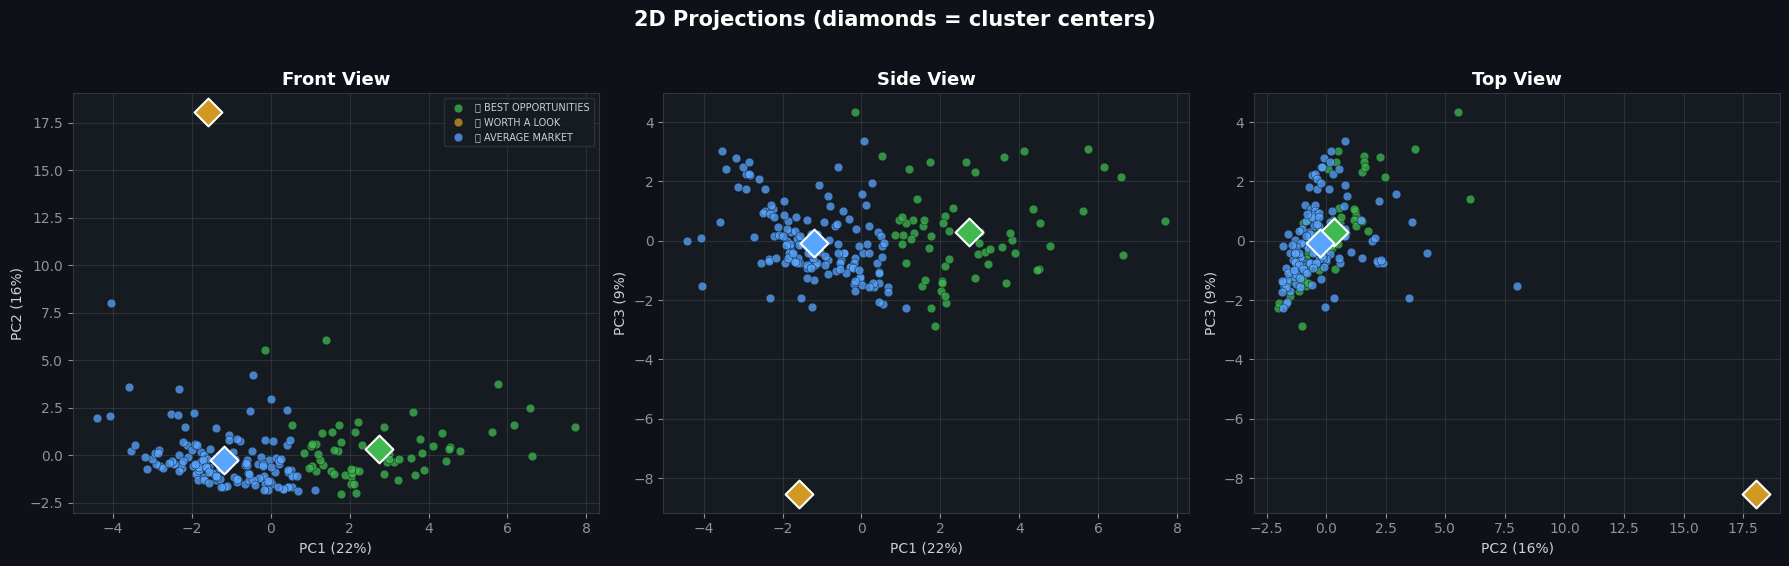

In [19]:
with plt.rc_context(DARK):
    fig, axes_2d = plt.subplots(1, 3, figsize=(18, 5.5))
    pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]
    titles_2d = ["Front View", "Side View", "Top View"]

    for ax, (px_, py_), title in zip(axes_2d, pairs, titles_2d):
        for c in rank_order:
            m = cluster_meta[c]
            sub = df[df["pca_cluster"] == c]
            ax.scatter(sub[px_], sub[py_], c=m["color"], s=40, alpha=0.75,
                       edgecolors="#0e1117", linewidths=0.4, label=m["label"], zorder=3)

        for c in rank_order:
            m = cluster_meta[c]
            ci = {"PC1": 0, "PC2": 1, "PC3": 2}
            cx = centroids[c][ci[px_]]
            cy = centroids[c][ci[py_]]
            ax.scatter(cx, cy, c=m["color"], s=200, marker="D", edgecolors="white",
                       linewidths=1.5, zorder=5)

        ax.set_xlabel(f"{px_} ({var[int(px_[-1])-1]:.0%})")
        ax.set_ylabel(f"{py_} ({var[int(py_[-1])-1]:.0%})")
        ax.set_title(title, fontsize=13, fontweight="bold", color="white")
        ax.grid(True, alpha=0.15)
        ax.spines[:].set_color("#30363d")

    axes_2d[0].legend(fontsize=7, facecolor="#161b22", edgecolor="#30363d",
                       labelcolor="#c9d1d9", loc="best")
    fig.suptitle("2D Projections (diamonds = cluster centers)",
                 fontsize=15, fontweight="bold", color="white", y=1.02)
    plt.tight_layout()
    plt.show()

---

## Step 7 — The Opportunity Map

Back to real numbers. **X-axis** = how long it's been sitting. **Y-axis** = price per sqft. **Dot size** = flip score.

Big green dots in the **bottom-right** = the money zone.

In [20]:
import plotly.express as px

if "days_on_market" in df.columns and "price_per_sqft" in df.columns:
    plot_df = df.dropna(subset=["days_on_market", "price_per_sqft"]).copy()
    plot_df["dot_size"] = (plot_df["flip_score"].clip(lower=1) * 1.5) + 2

    fig_opp = px.scatter(
        plot_df, x="days_on_market", y="price_per_sqft",
        color="pca_label", size="dot_size",
        hover_data={"address": True, "price": ":$,.0f", "sqft": True,
                    "beds": True, "flip_score": True,
                    "dot_size": False, "pca_label": True},
        color_discrete_map=color_map,
        template="plotly_dark",
    )
    med_ppsf = plot_df["price_per_sqft"].median()
    avg_dom = plot_df["days_on_market"].mean()

    fig_opp.add_hline(y=med_ppsf, line_dash="dash", line_color="#d29922",
                      annotation_text=f"median ${med_ppsf:,.0f}/sqft",
                      annotation_font_color="#d29922")
    fig_opp.add_vline(x=avg_dom, line_dash="dash", line_color="#d29922",
                      annotation_text=f"avg {avg_dom:.0f}d",
                      annotation_font_color="#d29922")

    fig_opp.add_shape(type="rect", x0=avg_dom, x1=plot_df["days_on_market"].max() * 1.05,
                      y0=plot_df["price_per_sqft"].min() * 0.9, y1=med_ppsf,
                      fillcolor="#3fb950", opacity=0.07, line_width=0)
    fig_opp.add_annotation(x=plot_df["days_on_market"].max() * 0.85,
                           y=plot_df["price_per_sqft"].min() * 1.1,
                           text="FLIP ZONE", showarrow=False,
                           font=dict(size=18, color="#3fb950", family="Arial Black"),
                           opacity=0.4)

    fig_opp.update_layout(
        paper_bgcolor="#0e1117", plot_bgcolor="#161b22",
        title=dict(text="Opportunity Map — bottom-right = where the money is",
                   font=dict(size=16, color="white")),
        xaxis_title="Days on Market", yaxis_title="Price per Sqft ($)",
        legend_title="Cluster", height=600,
    )
    fig_opp.show()

---

## Step 8 — Variance Explained

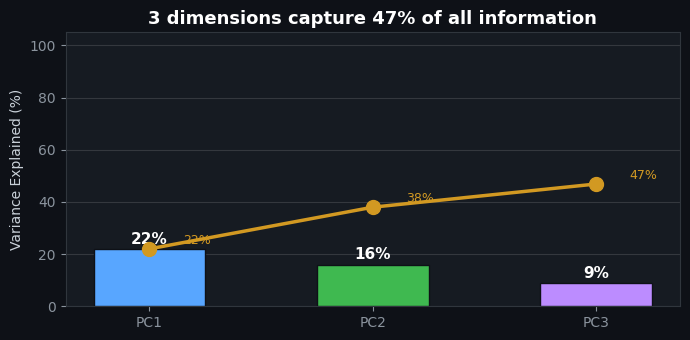

In [21]:
with plt.rc_context(DARK):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    cumvar = np.cumsum(var)
    ax.bar(["PC1", "PC2", "PC3"], var * 100,
           color=pc_colors, edgecolor="#0e1117", width=0.5, zorder=3)
    ax.plot(["PC1", "PC2", "PC3"], cumvar * 100, "o-", color="#d29922", lw=2.5,
            markersize=10, zorder=4)
    for i, (v, c) in enumerate(zip(var * 100, cumvar * 100)):
        ax.text(i, v + 2, f"{v:.0f}%", ha="center", color="white", fontsize=11, fontweight="bold")
        ax.text(i + 0.15, c + 2, f"{c:.0f}%", ha="left", color="#d29922", fontsize=9)
    ax.set_ylabel("Variance Explained (%)")
    ax.set_title(f"3 dimensions capture {cumvar[-1]:.0%} of all information",
                 fontsize=13, fontweight="bold", color="white")
    ax.set_ylim(0, 105)
    ax.spines[:].set_color("#30363d")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()

---

## The Picks

In [22]:
from IPython.display import display, Markdown

best_label = cluster_meta[rank_order[0]]["label"]
best = df[df["pca_label"] == best_label].copy()

display(Markdown(f"### {best_label} — {len(best)} properties"))
display(picks_table(best))

### 🔥 BEST OPPORTUNITIES — 61 properties

,address,city,zip,price,beds,baths,sqft,price_per_sqft,days_on_market,flip_score,cluster
0,20091 Annott St,Detroit,48205,$15K,2.0,1.0,747.0,$20,219,10,AVOID
1,19766 Stahelin Stahelin,Detroit,48219,$25K,2.0,1.0,1094.0,$23,196,9,GOLD
2,15780 Stansbury St,Detroit,48227,$35K,4.0,2.0,1824.0,$19,185,9,GOLD
3,20043 Wyoming Ave,Detroit,48221,$110K,4.0,3.0,2267.0,$48,201,9,GOLD
4,19230 Conley St,Detroit,48234,$20K,3.0,1.0,870.0,$23,979,9,AVOID
...,...,...,...,...,...,...,...,...,...,...,...
56,14554 Woodmont Ave,Detroit,48227,$290K,4.0,1.5,2024.0,$143,298,4,GOLD
57,18679 Santa Barbara Dr,Detroit,48221,$120K,3.0,1.0,1353.0,$89,63,3,PASS
58,15761 15759 Evergreen,Detroit,48223,$110K,5.0,2.0,1417.0,$78,48,3,PASS
59,20295 Huntington Rd,Detroit,48219,$130K,3.0,1.5,1245.0,$104,62,3,PASS


---

## How to read all of this

| What | How to read it |
|:---|:---|
| **PCA Loadings** | Which raw variables push properties along each axis. Long bars = strong influence. |
| **Elbow + Silhouette** | How we picked the number of groups. Green bar = best K. |
| **Radar charts** | Each cluster's "personality" — its strengths and weaknesses across 6 dimensions. |
| **3D Map** | Every property positioned by its DNA. Spin it. Hover. |
| **2D Projections** | Same data, flat views. Diamonds = group centers. |
| **Opportunity Map** | Real numbers. Bottom-right green zone = cheap + ignored = flip opportunity. |

**The math finds what your eyes can't.** These aren't hand-picked — the algorithm surfaced the natural clusters in the data.